In [1]:
import sys
sys.path.append('..')

import numpy as np
import matplotlib.pyplot as plt
from environments.monty_hall_2 import MontyHall2Env
from algorithms.monte_carlo import monte_carlo_es, on_policy_first_visit_mc_control, off_policy_mc_control
from algorithms.temporal_difference_learning import sarsa, q_learning
from algorithms.planning import dyna_q, dyna_q_plus
from eval import evaluate_policy

env = MontyHall2Env()

In [2]:
np.random.seed(0)
pi_mc_es, Q_mc_es = monte_carlo_es(env, gamma=0.999, num_episodes=30000)
results_mc_es = evaluate_policy(env, pi_mc_es, num_episodes=5000)
print("Monte Carlo ES :", results_mc_es)

Monte Carlo ES : {'mean_score': 0.1918, 'std_score': 0.3937, 'win_rate': 0.1918}


In [3]:
np.random.seed(0)
pi_on_mc, Q_on_mc = on_policy_first_visit_mc_control(env, gamma=0.999, epsilon=0.1, num_episodes=30000)
results_on_mc = evaluate_policy(env, pi_on_mc, num_episodes=5000)
print("On-policy MC :", results_on_mc)

On-policy MC : {'mean_score': 0.798, 'std_score': 0.4015, 'win_rate': 0.798}


In [4]:
np.random.seed(0)
pi_off_mc, Q_off_mc = off_policy_mc_control(env, gamma=0.999, num_episodes=30000)
results_off_mc = evaluate_policy(env, pi_off_mc, num_episodes=5000)
print("Off-policy MC :", results_off_mc)

Off-policy MC : {'mean_score': 0.799, 'std_score': 0.4007, 'win_rate': 0.799}


In [5]:
np.random.seed(0)
pi_sarsa, Q_sarsa = sarsa(env, gamma=0.999, alpha=0.1, epsilon=0.1, num_episodes=30000)
results_sarsa = evaluate_policy(env, pi_sarsa, num_episodes=5000)
print("Sarsa :", results_sarsa)

Sarsa : {'mean_score': 0.8014, 'std_score': 0.3989, 'win_rate': 0.8014}


In [6]:
np.random.seed(0)
pi_qlearning, Q_qlearning = q_learning(env, gamma=0.999, alpha=0.1, epsilon=0.1, num_episodes=30000)
results_qlearning = evaluate_policy(env, pi_qlearning, num_episodes=5000)
print("Q-Learning :", results_qlearning)

Q-Learning : {'mean_score': 0.8062, 'std_score': 0.3953, 'win_rate': 0.8062}


In [7]:
np.random.seed(0)
Q_dyna, pi_dyna = dyna_q(env, gamma=0.999, alpha=0.1, epsilon=0.1, max_steps=30000, N=10)
results_dyna = evaluate_policy(env, pi_dyna, num_episodes=5000)
print("Dyna-Q :", results_dyna)

np.random.seed(0)
Q_dyna_plus, pi_dyna_plus = dyna_q_plus(env, gamma=0.999, alpha=0.1, epsilon=0.1,
                                          max_steps=30000, N=10, kappa=0.001)
results_dyna_plus = evaluate_policy(env, pi_dyna_plus, num_episodes=5000)
print("Dyna-Q+ :", results_dyna_plus)

Dyna-Q : {'mean_score': 0.5964, 'std_score': 0.4906, 'win_rate': 0.5964}
Dyna-Q+ : {'mean_score': 0.7952, 'std_score': 0.4036, 'win_rate': 0.7952}


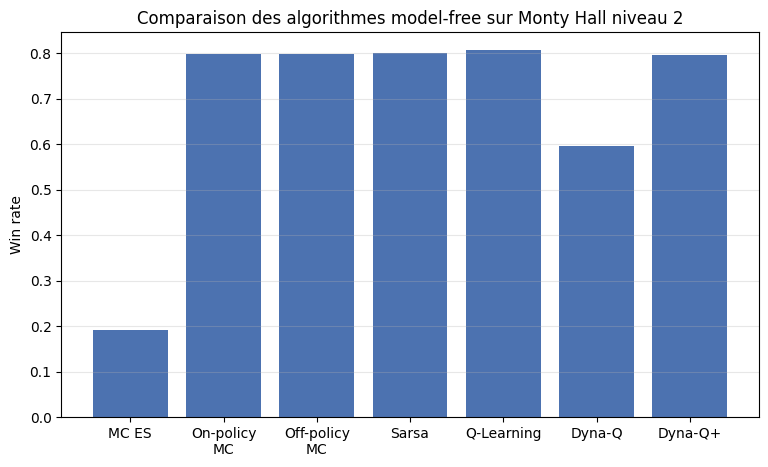

In [8]:
algos_names = ["MC ES", "On-policy\nMC", "Off-policy\nMC", "Sarsa", "Q-Learning", "Dyna-Q", "Dyna-Q+"]
win_rates_all = [results_mc_es["win_rate"], results_on_mc["win_rate"], results_off_mc["win_rate"],
                  results_sarsa["win_rate"], results_qlearning["win_rate"],
                  results_dyna["win_rate"], results_dyna_plus["win_rate"]]

plt.figure(figsize=(9, 5))
plt.bar(algos_names, win_rates_all, color="#4C72B0")
plt.ylabel("Win rate")
plt.title("Comparaison des algorithmes model-free sur Monty Hall niveau 2")
plt.grid(True, axis="y", alpha=0.3)
plt.savefig("montyhall2_comparaison_algos.png", dpi=100, bbox_inches="tight")
plt.show()